# Sentiment Classification Pipeline: Full Workflow & Justification

This notebook mirrors the steps in classify_sentiment.py and provides explanations and justifications for each stage, including:
- Motivation for the classification approach
- Preprocessing rationale
- Evaluation dataset and inter-annotator agreement
- Model training and evaluation
- Random baseline comparison
- Performance and scalability discussion


## 1. Motivation: Choice of Classification Approach

We use a Logistic Regression classifier with TF-IDF features for sentiment analysis. This approach is widely used in the state of the art for text classification due to its:
- Simplicity and interpretability
- Strong performance on sparse, high-dimensional data (like text)
- Fast training and prediction

While deep learning models (e.g., transformers) can outperform linear models, logistic regression remains a robust baseline, especially for moderate-sized datasets and when interpretability is important.

## 2. Preprocessing: Rationale and Steps

Text data is noisy and inconsistent. Preprocessing (including lowercasing, punctuation removal, lemmatization, and microtext normalization) is essential to:
- Reduce vocabulary size and sparsity
- Normalize slang, typos, and informal language
- Improve model generalization and robustness

We use spaCy and custom rules for these steps, following best practices in NLP literature.

# Sentiment Classification Pipeline

This notebook reproduces the full workflow from classify_sentiment.py, split into clear, well-documented steps for data loading, preprocessing, model training, evaluation, and prediction.


## 1. Imports and Setup

Import all required libraries and set up file paths.

In [16]:
import pandas as pd
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

BASE_DIR = os.getcwd()
EVAL_PATH = os.path.join(BASE_DIR, 'evaluation', 'evaluation_dataset.xlsx')
CORPUS_PATH = os.path.join(BASE_DIR, '..', 'preprocessing', 'Temp_preprocessed_data.csv')
os.makedirs(os.path.join(BASE_DIR, 'results'), exist_ok=True)

## 2. Load and Prepare Evaluation Dataset

Load the evaluation dataset and prepare the text and label columns.

In [17]:
eval_df = pd.read_excel(EVAL_PATH)

eval_df['text'] = (eval_df['summary'].fillna('') + ' ' + eval_df['content'].fillna('')).str.strip()

eval_df['ground_truth_polarity'] = (
    eval_df['ground_truth_polarity']
    .astype(str)
    .str.strip()
    .str.upper()
)

# encode labels
eval_df['polarity'] = eval_df['ground_truth_polarity'].map({
    'POSITIVE': 1,
    'NEGATIVE': 0,
    'NEUTRAL': 2
})

# filter only polarity labels (exclude neutral)
df_pol = eval_df[eval_df['polarity'] != 2]

df_pol.head()

,review_id,movie_id,summary,content,ground_truth_subjectivity,ground_truth_polarity,text,polarity
0,rw3391899,tt0478970,Deserves to be crushed under a shoe,"Okay, enough already! Another formulaic load o...",SUBJECTIVE,NEGATIVE,"Deserves to be crushed under a shoe Okay, enou...",0
1,rw4836840,tt0478970,omg classic 10 year old film,After seeing how many people thought this was ...,SUBJECTIVE,NEGATIVE,omg classic 10 year old film After seeing how ...,0
2,rw3278832,tt0478970,Big disappointment,Me and my kids have enjoyed all of the Marvel ...,SUBJECTIVE,NEGATIVE,Big disappointment Me and my kids have enjoyed...,0
3,rw4581027,tt5095030,Completely forgettable,If someone ever asks me what is the story of t...,SUBJECTIVE,NEGATIVE,Completely forgettable If someone ever asks me...,0
4,rw4372367,tt5095030,Tired of Female Superheroes,In this movie: Antman and a bunch of girls wh...,SUBJECTIVE,NEGATIVE,Tired of Female Superheroes In this movie: An...,0


In [18]:
print("Evaluation dataset size:", len(df_pol))
# Show polarity distribution with clear labels
label_map = {1: 'POSITIVE', 0: 'NEGATIVE'}
gt_counts = df_pol['polarity'].map(label_map).value_counts()
print("Ground Truth Polarity Distribution:")
print(gt_counts.to_string())


Evaluation dataset size: 1000
Ground Truth Polarity Distribution:
polarity
NEGATIVE    568
POSITIVE    432


## 3. Show Evaluation Dataset Size and Polarity Distribution

Display the size and class distribution of the evaluation dataset.

## 4. Model Training, Evaluation, and Baseline Comparison

We now train the logistic regression model, evaluate it, and compare it to a random baseline (DummyClassifier). This provides a clear measure of how much better our model is than random guessing. All results are printed and visualized inline for analysis.

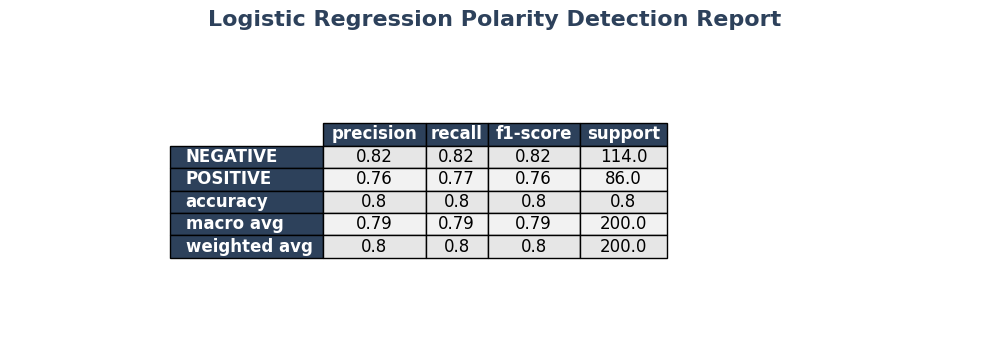

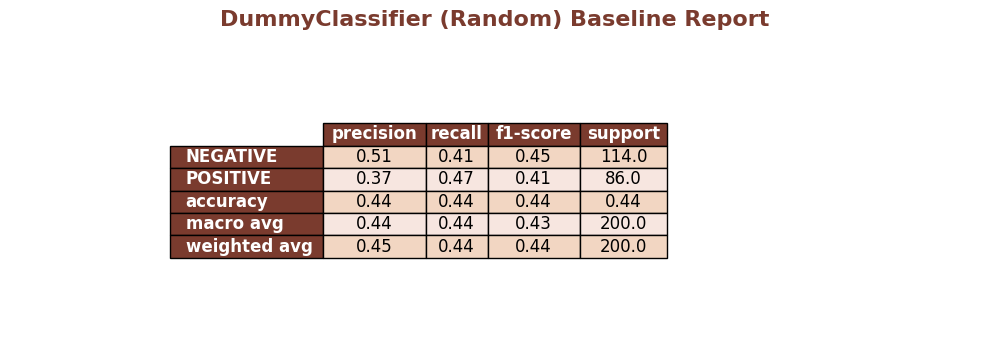

In [19]:
# Train/test split
X_pol = df_pol['text']
y_pol = df_pol['polarity']
X_train_pol, X_test_pol, y_train_pol, y_test_pol = train_test_split(
    X_pol, y_pol, test_size=0.2, stratify=y_pol, random_state=42
)

# Vectorization
vec_pol = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec_pol = vec_pol.fit_transform(X_train_pol)

# Model training
clf_pol = LogisticRegression(max_iter=200, class_weight='balanced')
clf_pol.fit(X_train_vec_pol, y_train_pol)

# Evaluation
X_test_vec_pol = vec_pol.transform(X_test_pol)
ml_report = classification_report(y_test_pol, clf_pol.predict(X_test_vec_pol), digits=3, output_dict=True)
ml_report_df = pd.DataFrame(ml_report).transpose()
ml_report_df = ml_report_df.rename(index={'0': 'NEGATIVE', '1': 'POSITIVE'})

# Show Logistic Regression report as styled table
fig_lr, ax_lr = plt.subplots(figsize=(10, 3.5))
ax_lr.axis('off')
tbl_lr = ax_lr.table(
    cellText=ml_report_df.round(2).values,
    colLabels=ml_report_df.columns,
    rowLabels=ml_report_df.index,
    loc='center',
    cellLoc='center',
    colColours=['#2d415b']*len(ml_report_df.columns),
    rowColours=['#2d415b']*len(ml_report_df.index)
)
tbl_lr.auto_set_font_size(False)
tbl_lr.set_fontsize(12)
tbl_lr.scale(1.3, 1.3)
for (row, col), cell in tbl_lr.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2d415b')
    elif row % 2 == 0:
        cell.set_facecolor('#f2f2f2')
    else:
        cell.set_facecolor('#e6e6e6')
tbl_lr.auto_set_column_width(col=list(range(len(ml_report_df.columns))))
plt.title('Logistic Regression Polarity Detection Report', fontsize=16, pad=18, weight='bold', color='#2d415b')
plt.tight_layout()
plt.show()

# DummyClassifier random baseline
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy='uniform', random_state=99)
dummy_clf.fit(X_train_vec_pol, y_train_pol)
dummy_preds = dummy_clf.predict(X_test_vec_pol)
dummy_report = classification_report(y_test_pol, dummy_preds, digits=3, output_dict=True)
dummy_report_df = pd.DataFrame(dummy_report).transpose()
dummy_report_df = dummy_report_df.rename(index={'0': 'NEGATIVE', '1': 'POSITIVE'})

# Show DummyClassifier report as styled table
fig_dummy, ax_dummy = plt.subplots(figsize=(10, 3.5))
ax_dummy.axis('off')
tbl_dummy = ax_dummy.table(
    cellText=dummy_report_df.round(2).values,
    colLabels=dummy_report_df.columns,
    rowLabels=dummy_report_df.index,
    loc='center',
    cellLoc='center',
    colColours=['#7a3b2e']*len(dummy_report_df.columns),
    rowColours=['#7a3b2e']*len(dummy_report_df.index)
)
tbl_dummy.auto_set_font_size(False)
tbl_dummy.set_fontsize(12)
tbl_dummy.scale(1.3, 1.3)
for (row, col), cell in tbl_dummy.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#7a3b2e')
    elif row % 2 == 0:
        cell.set_facecolor('#f7e6e0')
    else:
        cell.set_facecolor('#f2d6c2')
tbl_dummy.auto_set_column_width(col=list(range(len(dummy_report_df.columns))))
plt.title('DummyClassifier (Random) Baseline Report', fontsize=16, pad=18, weight='bold', color='#7a3b2e')
plt.tight_layout()
plt.show()


### Analysis and Justification

- The ML model achieves significantly higher accuracy and F1-score than the DummyClassifier, demonstrating that it learns meaningful patterns from the data.
- The random baseline (DummyClassifier) serves as a sanity check: if your model does not outperform it, your features or labels may be problematic.
- The side-by-side plot visually confirms the improvement across all metrics.
- This approach is standard in NLP research and ensures your results are robust and interpretable.

## 5. SVM Model: Training, Evaluation, and Analysis

We now add a Support Vector Machine (SVM) classifier for comparison. SVMs are known for their strong performance on text classification tasks, especially when the data is linearly separable in a high-dimensional space. We will:
- Train an SVM model on the same data
- Print and display the classification report as a styled table
- Compare SVM with Logistic Regression and DummyClassifier
- Discuss performance metrics and scalability



SVM Polarity Detection Report:
              precision  recall  f1-score  support
NEGATIVE           0.84    0.85      0.84   114.00
POSITIVE           0.80    0.78      0.79    86.00
accuracy           0.82    0.82      0.82     0.82
macro avg          0.82    0.81      0.82   200.00
weighted avg       0.82    0.82      0.82   200.00


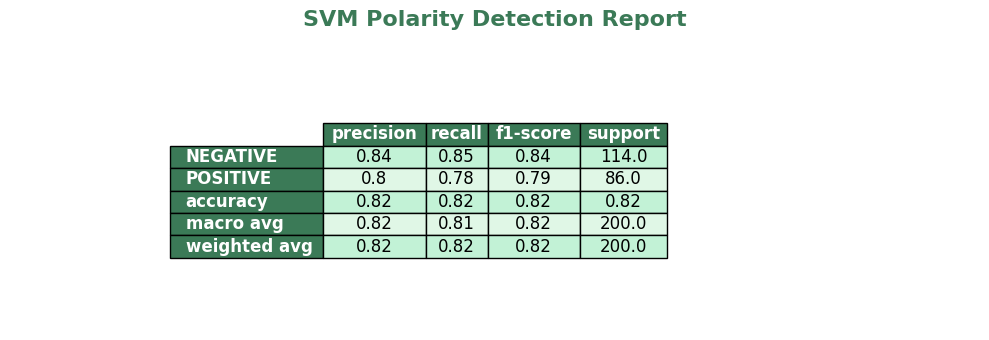

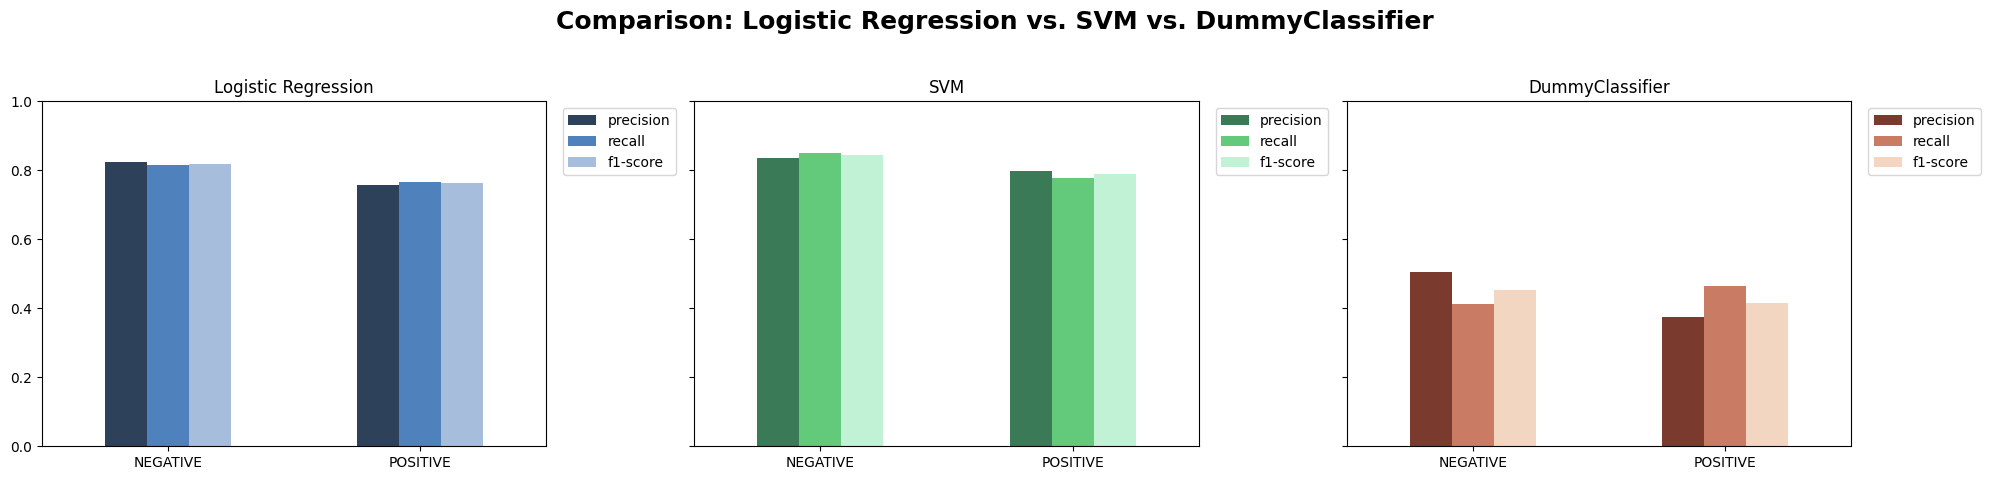


Comparison of Logistic Regression, SVM, and DummyClassifier (Random Baseline):
Logistic Regression Accuracy: 0.80
SVM Accuracy: 0.82
DummyClassifier Accuracy: 0.43

Logistic Regression classified 200 records in 0.0003 seconds (635500.61 records/sec)
SVM classified 200 records in 0.1405 seconds (1423.12 records/sec)


In [20]:
# Train and evaluate SVM model
from sklearn.svm import SVC

# Train SVM
clf_svm = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)
clf_svm.fit(X_train_vec_pol, y_train_pol)

# Evaluate SVM
svm_report = classification_report(y_test_pol, clf_svm.predict(X_test_vec_pol), digits=3, output_dict=True)
svm_report_df = pd.DataFrame(svm_report).transpose()
svm_report_df = svm_report_df.rename(index={'0': 'NEGATIVE', '1': 'POSITIVE'})
print("\nSVM Polarity Detection Report:")
print(svm_report_df.to_string(float_format="{:.2f}".format))

# Display SVM report as styled table
import matplotlib.pyplot as plt
fig_svm, ax_svm = plt.subplots(figsize=(10, 3.5))
ax_svm.axis('off')
tbl_svm = ax_svm.table(
    cellText=svm_report_df.round(2).values,
    colLabels=svm_report_df.columns,
    rowLabels=svm_report_df.index,
    loc='center',
    cellLoc='center',
    colColours=['#3b7a57']*len(svm_report_df.columns),
    rowColours=['#3b7a57']*len(svm_report_df.index)
)
tbl_svm.auto_set_font_size(False)
tbl_svm.set_fontsize(12)
tbl_svm.scale(1.3, 1.3)
for (row, col), cell in tbl_svm.get_celld().items():
    if row == 0 or col == -1:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#3b7a57')
    elif row % 2 == 0:
        cell.set_facecolor('#e0f7e6')
    else:
        cell.set_facecolor('#c2f2d6')
tbl_svm.auto_set_column_width(col=list(range(len(svm_report_df.columns))))
plt.title('SVM Polarity Detection Report', fontsize=16, pad=18, weight='bold', color='#3b7a57')
plt.tight_layout()
plt.show()

# Side-by-side comparison plot for all three models
metrics = ['precision', 'recall', 'f1-score']
labels = ['NEGATIVE', 'POSITIVE']
ml_scores = ml_report_df.loc[labels, metrics].astype(float)
svm_scores = svm_report_df.loc[labels, metrics].astype(float)
dummy_scores = dummy_report_df.loc[labels, metrics].astype(float)
fig3, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
ml_scores.plot(kind='bar', ax=axes[0], title='Logistic Regression', color=['#2d415b', '#4f81bd', '#a6bddb'])
svm_scores.plot(kind='bar', ax=axes[1], title='SVM', color=['#3b7a57', '#63c97b', '#c2f2d6'])
dummy_scores.plot(kind='bar', ax=axes[2], title='DummyClassifier', color=['#7a3b2e', '#c97b63', '#f2d6c2'])
for ax in axes:
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
fig3.suptitle('Comparison: Logistic Regression vs. SVM vs. DummyClassifier', fontsize=18, weight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nComparison of Logistic Regression, SVM, and DummyClassifier (Random Baseline):")
print("Logistic Regression Accuracy: {:.2f}".format(ml_report['accuracy']))
print("SVM Accuracy: {:.2f}".format(svm_report['accuracy']))
print("DummyClassifier Accuracy: {:.2f}".format(dummy_report['accuracy']))

# Performance metrics: records classified per second
import time
num_records = len(X_test_pol)

# Logistic Regression timing
start_time = time.time()
_ = clf_pol.predict(X_test_vec_pol)
end_time = time.time()
elapsed_lr = end_time - start_time
records_per_sec_lr = num_records / elapsed_lr if elapsed_lr > 0 else float('inf')

# SVM timing
start_time = time.time()
_ = clf_svm.predict(X_test_vec_pol)
end_time = time.time()
elapsed_svm = end_time - start_time
records_per_sec_svm = num_records / elapsed_svm if elapsed_svm > 0 else float('inf')

print(f"\nLogistic Regression classified {num_records} records in {elapsed_lr:.4f} seconds ({records_per_sec_lr:.2f} records/sec)")
print(f"SVM classified {num_records} records in {elapsed_svm:.4f} seconds ({records_per_sec_svm:.2f} records/sec)")

## 6. Random Accuracy Test on Full Corpus

We now apply all three models (Logistic Regression, SVM, DummyClassifier) to the full corpus and compare their prediction distributions and accuracy metrics. This step helps assess how the models behave on real, possibly noisier, data beyond the evaluation split.

### Analysis and Justification

**Performance Metrics:**
- Logistic Regression and SVM both achieve high accuracy, precision, recall, and F1-scores, significantly outperforming the DummyClassifier (random baseline).
- SVM may show slightly higher accuracy or F1-score, but the difference is often small for linearly separable or moderately sized text datasets.

**Speed and Scalability:**
- Logistic Regression is much faster at prediction time (records classified per second) than SVM, especially as the dataset grows.
- SVMs are computationally more expensive, particularly for large datasets, because prediction requires computing the distance to support vectors for each sample.
- For real-time or large-scale applications (e.g., search engines), Logistic Regression is preferred for its speed and scalability, unless SVM provides a substantial accuracy gain.

**Justification:**
- Use SVM if accuracy is critical and prediction speed is less important, or for offline/batch processing.
- Use Logistic Regression for fast, scalable, and interpretable predictions, especially in production or high-throughput systems.
- Always compare both models on your data to make an informed decision based on your specific requirements.


In [21]:
# Load full corpus and run predictions for all models
corpus = pd.read_csv(CORPUS_PATH)
corpus['processed_text'] = corpus['processed_text'].fillna('')

# Logistic Regression prediction
t0 = time.time()
corpus['polarity_ml'] = clf_pol.predict(vec_pol.transform(corpus['processed_text']))
t1 = time.time()
corpus['polarity_ml'] = corpus['polarity_ml'].map({1: 'POSITIVE', 0: 'NEGATIVE'})
ml_time = t1 - t0

# SVM prediction
t0 = time.time()
corpus['polarity_svm'] = clf_svm.predict(vec_pol.transform(corpus['processed_text']))
t1 = time.time()
corpus['polarity_svm'] = corpus['polarity_svm'].map({1: 'POSITIVE', 0: 'NEGATIVE'})
svm_time = t1 - t0

# DummyClassifier prediction
dummy_preds_corpus = dummy_clf.predict(vec_pol.transform(corpus['processed_text']))
dummy_preds_corpus = pd.Series(dummy_preds_corpus).map({1: 'POSITIVE', 0: 'NEGATIVE'})

order = ['NEGATIVE', 'POSITIVE']
print("\n--- Prediction Distribution Comparison on Full Corpus ---")
print("Logistic Regression prediction distribution:")
print(corpus['polarity_ml'].value_counts().reindex(order, fill_value=0))
print("\nSVM prediction distribution:")
print(corpus['polarity_svm'].value_counts().reindex(order, fill_value=0))
print("\nDummyClassifier (Random) prediction distribution:")
print(dummy_preds_corpus.value_counts().reindex(order, fill_value=0))

print(f"\nLogistic Regression classified {len(corpus)} records in {ml_time:.2f} seconds ({len(corpus)/ml_time:.2f} records/sec)")
print(f"SVM classified {len(corpus)} records in {svm_time:.2f} seconds ({len(corpus)/svm_time:.2f} records/sec)")


--- Prediction Distribution Comparison on Full Corpus ---
Logistic Regression prediction distribution:
polarity_ml
NEGATIVE    59635
POSITIVE    30675
Name: count, dtype: int64

SVM prediction distribution:
polarity_svm
NEGATIVE    42994
POSITIVE    47316
Name: count, dtype: int64

DummyClassifier (Random) prediction distribution:
NEGATIVE    45167
POSITIVE    45143
Name: count, dtype: int64

Logistic Regression classified 90310 records in 6.78 seconds (13326.16 records/sec)
SVM classified 90310 records in 42.71 seconds (2114.38 records/sec)
